# Member B: Decision Tree + Random Forest + eli5/LIME Interpretability
## CS667 Project 4: ML Interpretability

**Assigned Tasks:**
- EDA Focus: Feature distributions
- Models: Decision Tree + Random Forest with GridSearchCV
- Interpretability: eli5 for DT (Task 3_B) + LIME for RF (Task 3_C partial)

**Prerequisites:** Run `00_data_preparation.ipynb` first!

---
# Part 1: Setup and Data Loading

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import joblib

import eli5
from eli5.sklearn import PermutationImportance

import lime
import lime.lime_tabular

# Shared constants
RANDOM_STATE = 42
TARGET_COLUMN = 'DEATH_EVENT'

# Example (team should verify/change these):
POSITIVE_EXAMPLE_IDX = 124
NEGATIVE_EXAMPLE_IDX = 131

# Sets Plot Font Size
plt.rcParams.update({'font.size': 16}) 

In [96]:
# Load the pre-split data
train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

X_train = train_data.drop(columns=[TARGET_COLUMN, 'time'])
y_train = train_data[TARGET_COLUMN]
X_test = test_data.drop(columns=[TARGET_COLUMN, 'time'])
y_test = test_data[TARGET_COLUMN]

feature_names = X_train.columns.tolist()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_names}")

Training samples: 89
Test samples: 210
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


---
# Part 2: Exploratory Data Analysis

**Your EDA Focus**: Feature distributions (univariate analysis).

### Investigation Prompts:
> - How are continuous features distributed? Are there outliers?
> - What is the distribution of binary features across the two classes?
> - Do any features show clear separation between death/survival groups?

In [97]:
# Define feature types
BINARY_FEATURES = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
CONTINUOUS_FEATURES = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 
                       'platelets', 'serum_creatinine', 'serum_sodium']

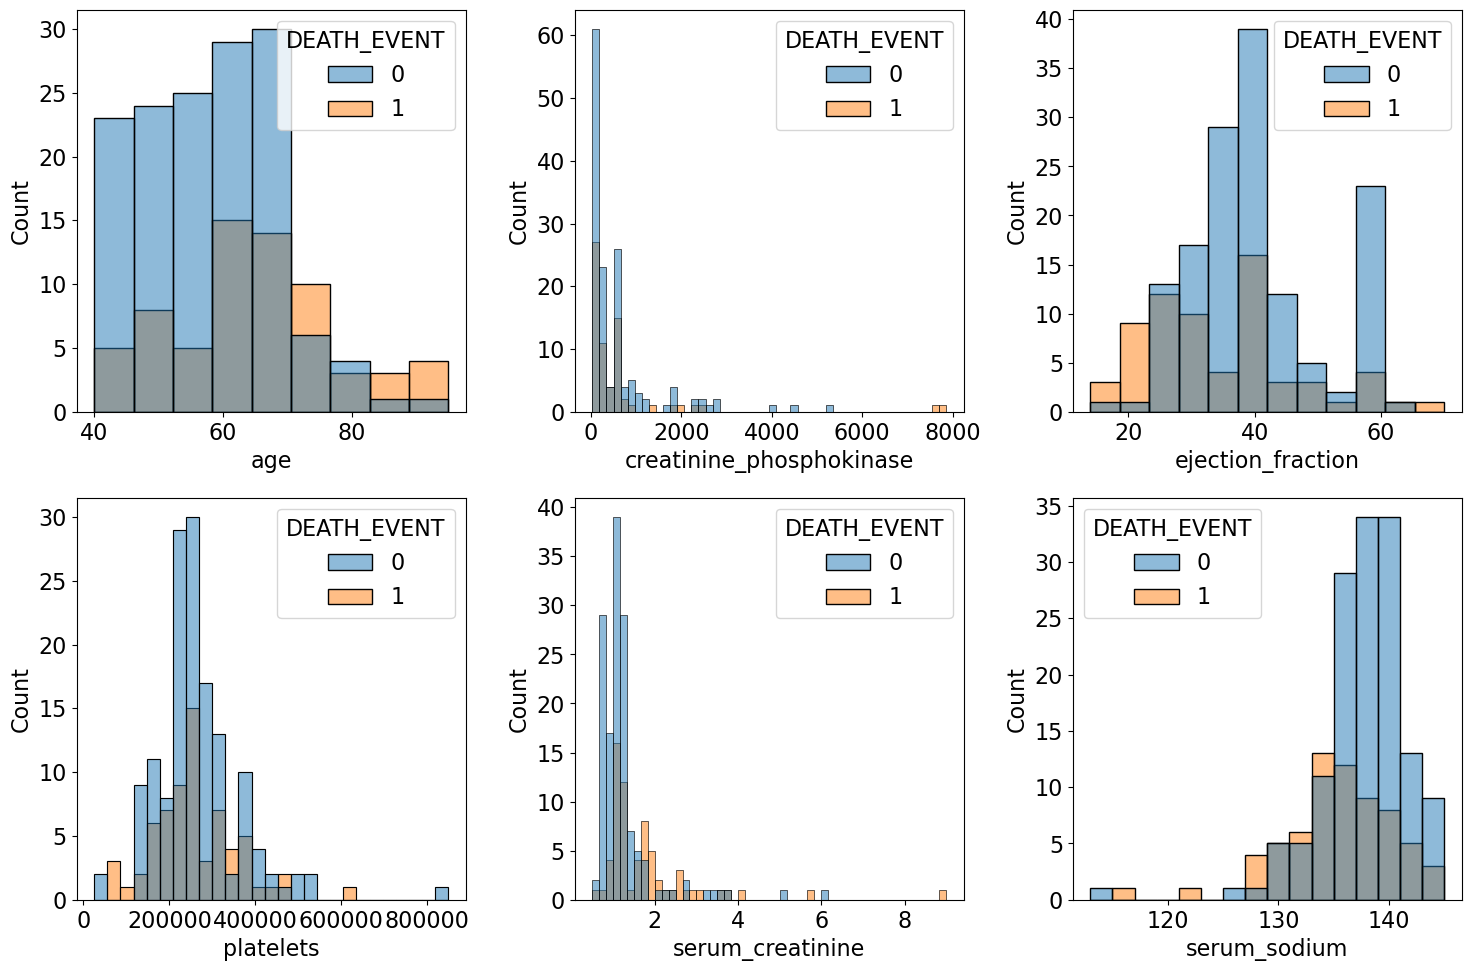

In [101]:
# TODO: Create histograms for continuous features, colored by target
# Hint: Use train_data for EDA, with hue=TARGET_COLUMN


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(CONTINUOUS_FEATURES):
    sns.histplot(
        data=test_data,
        x=feature,
        hue=TARGET_COLUMN,
        ax=axes[i],
        multiple='layer',
        alpha=.5
    )

# for j in range(len(CONTINUOUS_FEATURES), 3*3):
#     axes[j].axis("off")

plt.tight_layout()
plt.savefig('../visualizations/continuous_distributions.png', dpi=150)
plt.show()

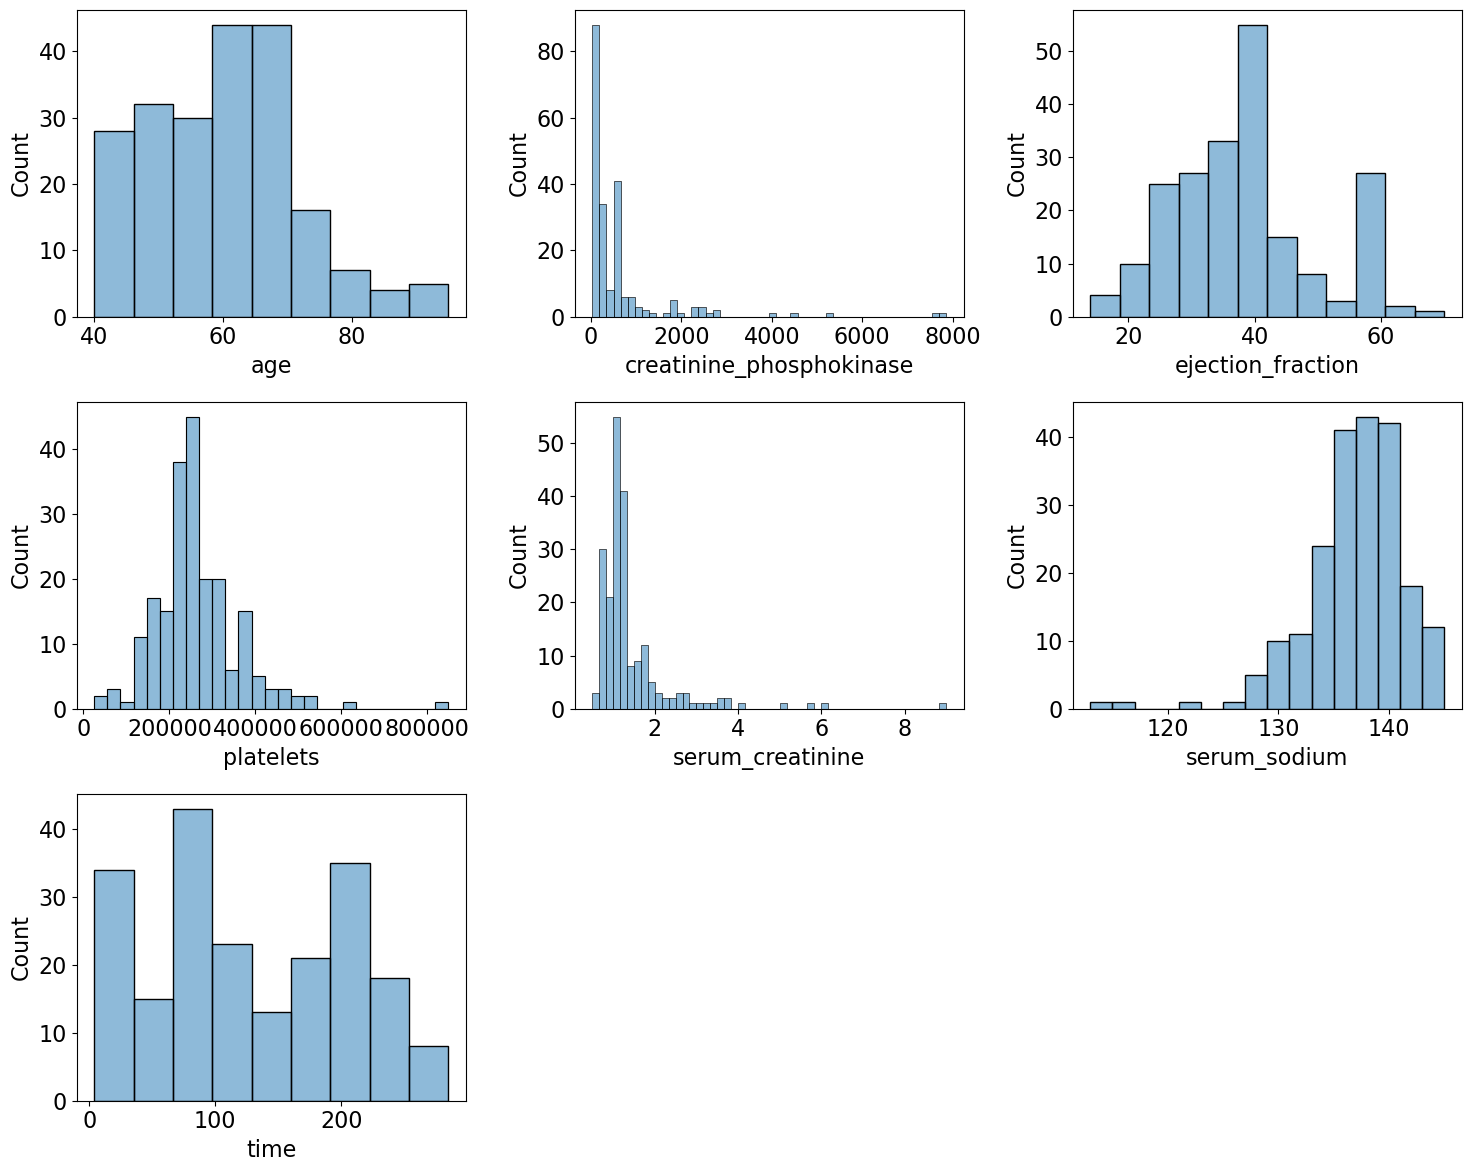

In [76]:
# TODO: Create histograms for continuous features, colored by target
# Hint: Use train_data for EDA, with hue=TARGET_COLUMN


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(CONTINUOUS_FEATURES):
    sns.histplot(
        data=test_data,
        x=feature,
        # hue=TARGET_COLUMN,
        ax=axes[i],
        multiple='layer',
        alpha=.5
    )

for j in range(len(CONTINUOUS_FEATURES), 3*3):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig('../visualizations/continuous_distributions.png', dpi=150)
plt.show()

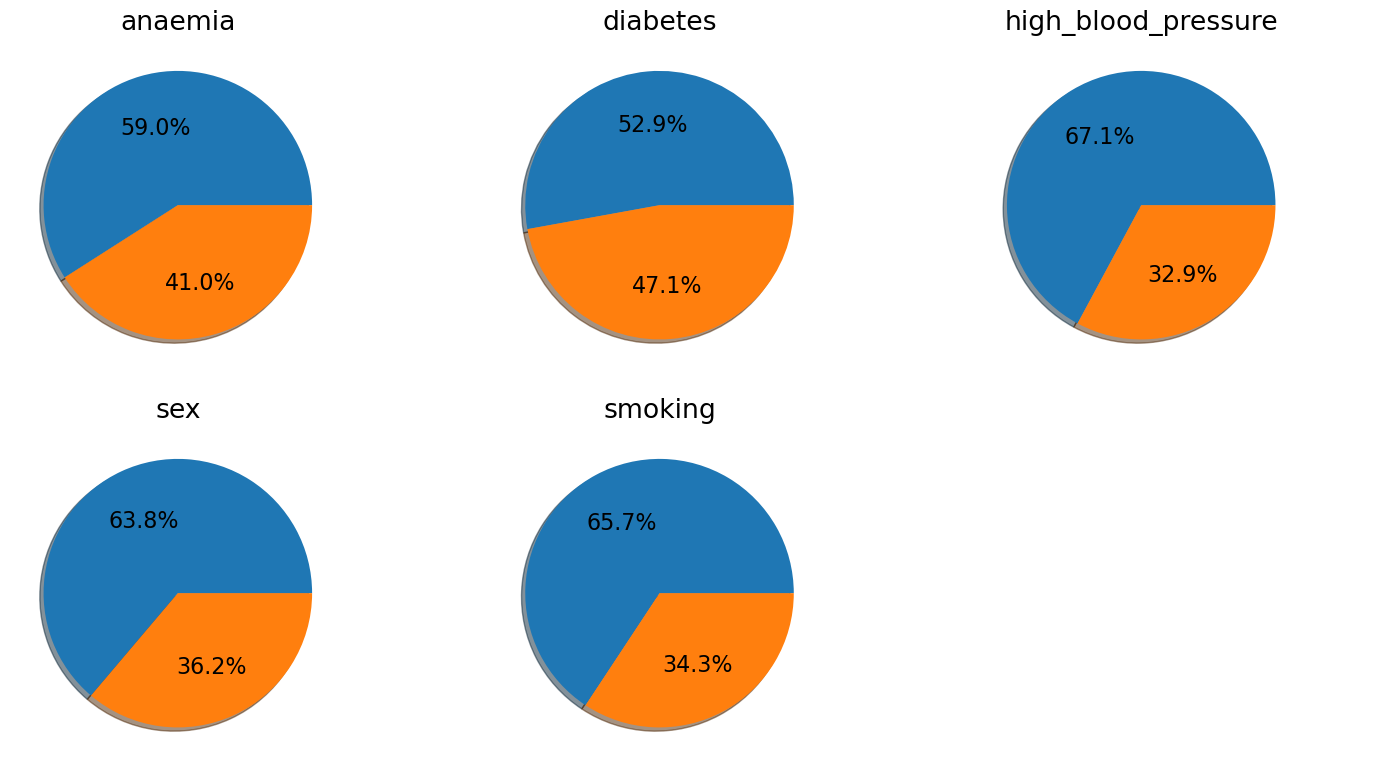

In [102]:
# TODO: Create bar plots for binary features, showing proportions by target
# Hint: Crosstab or groupby can help calculate proportions

# Its easier to just do Pie charts and have it automaticaly show the persentages.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(BINARY_FEATURES):
    counts = test_data[feature].value_counts()
    axes[i].pie(counts, autopct='%1.1f%%', shadow=True)
    axes[i].set_title(feature)
    # sns.barplot(
    #     data=train_data,
    #     x=feature,
    #     y=TARGET_COLUMN,
    #     ax=axes[i],
    #     errorbar=None
    # )

for j in range(len(BINARY_FEATURES), 2*3):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig('../visualizations/binary_distributions.png', dpi=150)
plt.show()

### EDA Findings:

*Document your key observations:*

1. Features showing clear separation between classes: Time.
2. Outliers detected in:
    - Creatinine_Phospokinase
    - Serum_Creatinine
    - Platelets
    - Serum_Sodium
3. Skewed distributions:
    - Time is right skewed for the death event class(but well balanced )
    - Serum_Sodium is slightly left skewed(once outliers are discarded)
    - Ejection Fraction is slightly skewed right
4. Implications for tree-based models:
    - 

---
# Part 3: Decision Tree Modeling

### Investigation Prompts:
> - What hyperparameters control Decision Tree complexity?
> - What is the risk of overfitting with deep trees?
> - Why don't trees require feature scaling?

In [103]:
# TODO: Define the hyperparameter grid for Decision Tree
# Consider: max_depth, min_samples_split, min_samples_leaf, criterion

dt_param_grid = {
    # YOUR CODE HERE
    # 'max_depth': [3, 5, 7, 10, None],
    # 'min_samples_split': [2, 5, 10],
    # 'min_samples_leaf': [1, 2, 4]
    'criterion': ['gini', 'entropy'], # Quality of split
    'max_depth': [3, 5, 10, 15, None], # Max levels
    'min_samples_split': [2, 5, 10, 20], # Min samples to split node
    'min_samples_leaf': [1, 2, 4, 8], # Min samples in a leaf
    'max_features': ['sqrt', 'log2', None] # Features considered at each split
}

print(f"DT Parameter grid: {dt_param_grid}")

DT Parameter grid: {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 10, 15, None], 'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8], 'max_features': ['sqrt', 'log2', None]}


In [104]:
# TODO: Perform GridSearchCV for Decision Tree

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid_search = GridSearchCV(
    dt, param_grid=dt_param_grid
)

# Fit
dt_grid_search.fit(X_train, y_train)

print(f"Best DT parameters: {dt_grid_search.best_params_}")
print(f"Best DT CV AUC-ROC: {dt_grid_search.best_score_:.4f}")

Best DT parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best DT CV AUC-ROC: 0.7425


In [105]:
# Evaluate Decision Tree on test set
best_dt = dt_grid_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc_roc = roc_auc_score(y_test, y_proba_dt)

print(f"\n=== Decision Tree Results ===")
print(f"Test Accuracy: {dt_accuracy:.4f}")
print(f"Test AUC-ROC: {dt_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


=== Decision Tree Results ===
Test Accuracy: 0.7333
Test AUC-ROC: 0.7636

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       143
           1       0.59      0.52      0.56        67

    accuracy                           0.73       210
   macro avg       0.69      0.68      0.68       210
weighted avg       0.73      0.73      0.73       210



In [106]:
# Save Decision Tree model
joblib.dump(best_dt, '../models/decision_tree_best.pkl')
print("Decision Tree model saved.")

Decision Tree model saved.


---
# Part 4: Random Forest Modeling

### Investigation Prompts:
> - How does Random Forest differ from a single Decision Tree?
> - What is the effect of n_estimators on performance vs. computation?
> - Why might Random Forest be more robust than a single tree?

In [107]:
# TODO: Define the hyperparameter grid for Random Forest
# Consider: n_estimators, max_depth, min_samples_split, max_features

rf_param_grid = {
    # YOUR CODE HERE
    # Hint: 'n_estimators': [50, 100, 200]
    # Hint: 'max_depth': [5, 10, 15, None]
    # Hint: 'max_features': ['sqrt', 'log2']
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'], # Common choices
    'criterion': ['gini', 'entropy']
}

print(f"RF Parameter grid: {rf_param_grid}")

RF Parameter grid: {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2'], 'criterion': ['gini', 'entropy']}


In [108]:
# TODO: Perform GridSearchCV for Random Forest

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf_grid_search = GridSearchCV(
    rf, rf_param_grid
)

# Fit
rf_grid_search.fit(X_train, y_train)

print(f"Best RF parameters: {rf_grid_search.best_params_}")
print(f"Best RF CV AUC-ROC: {rf_grid_search.best_score_:.4f}")

Best RF parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best RF CV AUC-ROC: 0.7425


In [110]:
# Evaluate Random Forest on test set
best_rf = rf_grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc_roc = roc_auc_score(y_test, y_proba_rf)

print(f"\n=== Random Forest Results ===")
print(f"Test Accuracy: {rf_accuracy:.4f}")
print(f"Test AUC-ROC: {rf_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== Random Forest Results ===
Test Accuracy: 0.7524
Test AUC-ROC: 0.7884

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       143
           1       0.66      0.46      0.54        67

    accuracy                           0.75       210
   macro avg       0.72      0.68      0.69       210
weighted avg       0.74      0.75      0.74       210



In [115]:
# Save Random Forest model
joblib.dump(best_rf, '../models/random_forest_best.pkl')
print("Random Forest model saved.")

Random Forest model saved.


---
# Part 5: eli5 for Decision Tree (Task 3_B)

## eli5 Investigation Prompts for Trees

> **Research these questions:**
> 
> 1. How does eli5 calculate feature importance for Decision Trees?
> 2. What does `eli5.show_prediction()` show for tree-based models vs. linear models?
> 3. How can you trace the decision path through a tree for a specific prediction?
> 4. Why might eli5 feature importance differ from sklearn's `feature_importances_`?

### 5.1 Feature Importance with eli5

In [112]:
# TODO: Use eli5.show_weights() to display feature importance
# Hint: Pass feature_names for readability

eli5.show_weights(best_dt, feature_names=list(X_test.columns))

Weight,Feature
0.3865,serum_creatinine
0.3236,ejection_fraction
0.1313,age
0.0663,high_blood_pressure
0.0485,smoking
0.0438,platelets
0,sex
0,serum_sodium
0,diabetes
0,creatinine_phosphokinase


In [113]:
# TODO: Compare with sklearn's built-in feature_importances_
# Are they the same? Why or why not?

sklearn_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("sklearn feature_importances_:")
print(sklearn_importance)

sklearn feature_importances_:
                     feature  importance
7           serum_creatinine    0.386504
4          ejection_fraction    0.323646
0                        age    0.131294
5        high_blood_pressure    0.066282
10                   smoking    0.048474
6                  platelets    0.043799
1                    anaemia    0.000000
2   creatinine_phosphokinase    0.000000
3                   diabetes    0.000000
8               serum_sodium    0.000000
9                        sex    0.000000


### 5.2 Explain Specific Predictions

In [127]:
# Find indices for positive and negative examples
positive_idx = y_test[y_test == 1].index[0]
negative_idx = y_test[y_test == 0].index[0]

print(f"Positive example index: {positive_idx}")
print(f"Negative example index: {negative_idx}")
print(X_test.iloc[positive_idx])
print(X_test.iloc[negative_idx])

Positive example index: 1
Negative example index: 0
age                             95.0
anaemia                          1.0
creatinine_phosphokinase       371.0
diabetes                         0.0
ejection_fraction               30.0
high_blood_pressure              0.0
platelets                   461000.0
serum_creatinine                 2.0
serum_sodium                   132.0
sex                              1.0
smoking                          0.0
Name: 1, dtype: float64
age                             60.0
anaemia                          1.0
creatinine_phosphokinase      1082.0
diabetes                         1.0
ejection_fraction               45.0
high_blood_pressure              0.0
platelets                   250000.0
serum_creatinine                 6.1
serum_sodium                   131.0
sex                              1.0
smoking                          0.0
Name: 0, dtype: float64


In [128]:
# TODO: Explain prediction for POSITIVE example using eli5
# Hint: For trees, eli5.show_prediction() traces the decision path

print("=== Decision Tree Explanation for POSITIVE Example ===")

pos_row = X_test.iloc[positive_idx]
eli5.show_prediction(best_dt, doc=pos_row, feature_names = X_train.columns.to_list())

=== Decision Tree Explanation for POSITIVE Example ===


In [129]:
# TODO: Explain prediction for NEGATIVE example

print("=== Decision Tree Explanation for NEGATIVE Example ===")
# YOUR CODE HERE

pos_row = X_train.iloc[negative_idx]
eli5.show_prediction(best_dt, pos_row, feature_names = X_train.columns.to_list())

=== Decision Tree Explanation for NEGATIVE Example ===


---
# Part 6: LIME for Random Forest (Task 3_C partial)

## LIME Investigation Prompts

> **Research these questions:**
> 
> 1. What does LIME stand for, and what is "local" interpretability?
> 2. What parameters does `LimeTabularExplainer` require and why?
> 3. What do the coefficients from `explain_instance()` represent?
> 4. What does a low R² value tell you about the LIME explanation?
> 5. How do you access `local_exp`, `intercept`, and `score` from an explanation?

### 6.1 Create LIME Explainer

In [ ]:
# TODO: Create a LimeTabularExplainer
# Hint: You need training_data, feature_names, class_names, mode

explainer = lime.lime_tabular.LimeTabularExplainer(
    # YOUR CODE HERE
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Survived', 'Death'],
    mode='classification',
    
)

print("LIME explainer created.")

LIME explainer created.


### 6.2 Explain Predictions with LIME

In [142]:
# TODO: Explain a POSITIVE example prediction
# Use explain_instance() with the RF's predict_proba

pos_idx_loc = list(X_test.index).index(positive_idx)
pos_instance = X_test.iloc[pos_idx_loc].values

# YOUR CODE HERE
exp_positive = explainer.explain_instance(
    pos_instance,
    best_dt.predict_proba

)

print("=== LIME Explanation for POSITIVE Example ===")
exp_positive.show_in_notebook()  # or use as_list()

=== LIME Explanation for POSITIVE Example ===


c:\Users\watso\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [138]:
# TODO: Access the LIME linear model details
# The project requires: coefficients, intercept, and R²

# YOUR CODE HERE
# Hint: exp_positive.local_exp gives feature contributions
# Hint: exp_positive.intercept gives the intercept
# Hint: exp_positive.score gives the R² of the local linear model

print("\nLIME Linear Model Details (Positive Example):")
print(f"Intercept: {exp_positive.intercept}")
print(f"R² Score: {exp_positive.score}")
print(f"Coefficients: {exp_positive.local_exp}")


LIME Linear Model Details (Positive Example):
Intercept: {1: np.float64(0.20105820347457062)}
R² Score: 0.5076388159215453
Coefficients: {1: [(np.int64(7), np.float64(0.4520497020774599)), (np.int64(4), np.float64(0.31937685977036673)), (np.int64(0), np.float64(0.145856106349418)), (np.int64(10), np.float64(-0.06452226105512394)), (np.int64(5), np.float64(-0.0500609732992588)), (np.int64(8), np.float64(-0.01814874183440816)), (np.int64(6), np.float64(-0.016280194628747018)), (np.int64(2), np.float64(0.012191148908867007)), (np.int64(3), np.float64(-0.010557649449012104)), (np.int64(9), np.float64(0.010304782658285976))]}


In [ ]:
# TODO: Explain a NEGATIVE example prediction

neg_idx_loc = list(X_test.index).index(negative_idx)
neg_instance = X_test.iloc[neg_idx_loc].values

print("=== LIME Explanation for NEGATIVE Example ===")
# YOUR CODE HERE
exp_negative = explainer.explain_instance(
    neg_instance,
    best_dt.predict_proba

)
print("\nLIME Linear Model Details (Positive Example):")
print(f"Intercept: {exp_negative.intercept}")
print(f"R² Score: {exp_negative.score}")
print(f"Coefficients: {exp_negative.local_exp}")


print("=== LIME Explanation for POSITIVE Example ===")
exp_negative.show_in_notebook()  # or use as_list()

=== LIME Explanation for NEGATIVE Example ===

LIME Linear Model Details (Positive Example):
Intercept: {1: np.float64(0.35934796102793765)}
R² Score: 0.3541072502895092
Coefficients: {1: [(np.int64(7), np.float64(0.45636481428251935)), (np.int64(4), np.float64(-0.13220117032660014)), (np.int64(10), np.float64(-0.08548922032369759)), (np.int64(5), np.float64(-0.045848484113864336)), (np.int64(0), np.float64(-0.043539310975000564)), (np.int64(3), np.float64(0.018213511573154862)), (np.int64(1), np.float64(0.011025391093787883)), (np.int64(9), np.float64(0.010251640433030331)), (np.int64(8), np.float64(-0.009864110310256628)), (np.int64(2), np.float64(-0.003952872619066022))]}
=== LIME Explanation for POSITIVE Example ===


c:\Users\watso\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### 6.3 LIME Interpretation Summary

*Document your LIME findings:*

1. **R² Score Analysis:**
   - Positive example R²: ...
   - Negative example R²: ...
   - Is the local linear approximation trustworthy?

2. **Key Feature Contributions:**
   - Positive example top features: ...
   - Negative example top features: ...

3. **Comparison with eli5 (Decision Tree):**
   - How do LIME explanations for RF compare to eli5 for DT?
   - Any consistent features across both methods?

---
# Part 7: Individual Predictions for Task 4

In [145]:
# TODO: Fill in the agreed indices from team discussion
POSITIVE_EXAMPLE_IDX = 55  # Update with team-agreed index
NEGATIVE_EXAMPLE_IDX = 131  # Update with team-agreed index

if POSITIVE_EXAMPLE_IDX is None:
    print("WARNING: Update example indices!")

In [147]:
def predict_with_proba(model, X, idx, true_label, model_name):
    """Generate prediction output for Task 4 format."""
    pos = list(X.index).index(idx)
    sample = X.iloc[pos:pos+1]
    
    proba = model.predict_proba(sample)[0]
    pred = model.predict(sample)[0]
    
    print(f"{model_name} Prediction: {pred}")
    print(f"{model_name} Probabilities: [P(Survive)={proba[0]:.4f}, P(Death)={proba[1]:.4f}]")

if POSITIVE_EXAMPLE_IDX is not None:
    print("=== Positive Example (True Label: 1) ===")
    predict_with_proba(best_dt, X_test, POSITIVE_EXAMPLE_IDX, 1, "DT")
    predict_with_proba(best_rf, X_test, POSITIVE_EXAMPLE_IDX, 1, "RF")
    
    print("\n=== Negative Example (True Label: 0) ===")
    predict_with_proba(best_dt, X_test, NEGATIVE_EXAMPLE_IDX, 0, "DT")
    predict_with_proba(best_rf, X_test, NEGATIVE_EXAMPLE_IDX, 0, "RF")

=== Positive Example (True Label: 1) ===
DT Prediction: 0
DT Probabilities: [P(Survive)=0.8824, P(Death)=0.1176]
RF Prediction: 0
RF Probabilities: [P(Survive)=0.8833, P(Death)=0.1167]

=== Negative Example (True Label: 0) ===
DT Prediction: 0
DT Probabilities: [P(Survive)=0.8824, P(Death)=0.1176]
RF Prediction: 0
RF Probabilities: [P(Survive)=0.7120, P(Death)=0.2880]


---
# Part 8: Summary for Merge

### Decision Tree Results:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | ... |
| Test Accuracy | ... |
| Test AUC-ROC | ... |

### Random Forest Results:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | ... |
| Test Accuracy | ... |
| Test AUC-ROC | ... |

### Files Saved:
- `../models/decision_tree_best.pkl`
- `../models/random_forest_best.pkl`
- `../visualizations/continuous_distributions.png`
- `../visualizations/binary_distributions.png`

### Key Interpretability Findings:
1. eli5 (Decision Tree): ...
2. LIME (Random Forest): ...
3. R² assessment: ...